# Buckling of cross-ply plates in uniaxial compression: Noor (1975)

A. K. Noor, *Stability of multilayered composite plates*, Fibre Science and Technology 8 (1975) 81-89.

Square cross-ply plates, simply supported on the four edges (SS-1), under the uniaxial compression $N_{xx}$, with the 3D elasticity solution of the linear buckling problem as reference:

- material: $G_{LT} = 0.6 E_T$, $G_{TT} = 0.5 E_T$, $\nu_{LT} = \nu_{TT} = 0.25$ and $E_L/E_T$ from 3 to 40;
- lay-ups with $N_L$ layers, the top layer at 0 deg (along the load), antisymmetric with an even number of layers ($N_L$ = 2, 4, 6, 10) and symmetric with an odd number ($N_L$ = 3, 5, 9), the 0 and 90 deg layers having the same total thickness (p. 84);
- Table 2: 3D buckling load $\bar{N} = N_{cr} a^2/(E_T h^3)$ for $a/h = 10$ and $E_L/E_T$ = 3, 10, 20, 30, 40;
- Table 3: $E_L/E_T = 30$, $a/h = 10$ and 5, $N_L$ = 2, 3, 9, 10, the 3D values and the ratios $N_{SDT}/N_{3D}$ of Noor's shear deformation theory with $\kappa = 1$, $\kappa = 5/6$ and the composite factors of his Table 1, which follow Chow and Whitney;
- Table 1: the composite shear correction factors for $E_L/E_T = 30$.

The data are those of `REFERENCE_DATA.md` of the paper study, copied in `scf_validation_utils.py`.

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from composites import laminated_plate
from structsolve import lb

import scf_validation_utils as su
from scf_validation_utils import pct, markdown_table

# True runs panels again, otherwise the results saved in RESULTS are loaded
RERUN = False
RESULTS = 'results'

## Laminates and shear correction factors

The plies of Noor's laminates, `noor_plyts`, and his composite factors of Table 1 against the factors $\kappa_{13}$ (along the fibres of the top layer) and $\kappa_{23}$ of `'whitney'` in `composites`, for $E_L/E_T = 30$, together with those of the other corrections compared below.

In [2]:
E2 = 1.
SCFS = ['K1', 'K56', 'WHI', 'VLA', 'ROH', 'BB', 'TSF']


def laminaprop(E1E2):
    return (E1E2*E2, E2, 0.25, 0.6*E2, 0.6*E2, 0.5*E2)


def cross_ply(num_layers):
    return [0 if i % 2 == 0 else 90 for i in range(num_layers)]


def noor_plyts(stack, h):
    r'''Same total thickness of the 0 and 90 deg layers (Noor, p. 84)'''
    n0 = sum(1 for t in stack if t == 0)
    n90 = len(stack) - n0
    return [h/2/n0 if t == 0 else h/2/n90 for t in stack]


rows = []
for NL, (k1, k2) in su.NOOR_1975_TABLE_1.items():
    stack = cross_ply(NL)
    args = (stack, noor_plyts(stack, 1.), [laminaprop(30)]*NL, [1.]*NL)
    w13, w23 = su.kappas('WHI', *args)
    rows.append([NL, 'antisymmetric' if NL % 2 == 0 else 'symmetric', '%.4f / %.4f' % (k1, k2), '%.4f / %.4f' % (w13, w23)]
                + ['%.4f / %.4f' % su.kappas(k, *args) for k in ('VLA', 'ROH', 'BB', 'TSF')])
display(Markdown(markdown_table(['$N_L$', 'laminate', 'Noor, Table 1', "'whitney'", "'vlachoutsis'", "'rohwer'",
                                 "'birman_bert'", "'thickness_shear'"], rows)))

| $N_L$ | laminate | Noor, Table 1 | 'whitney' | 'vlachoutsis' | 'rohwer' | 'birman_bert' | 'thickness_shear' |
|---|---|---|---|---|---|---|---|
| 2 | antisymmetric | 0.6421 / 0.6421 | 0.6421 / 0.6421 | 0.6421 / 0.6421 | 0.6417 / 0.6417 | 1.0571 / 1.0571 | 0.8140 / 0.8140 |
| 4 | antisymmetric | 0.6523 / 0.6523 | 0.6523 / 0.6523 | 0.6523 / 0.6523 | 0.6522 / 0.6522 | 0.9981 / 0.9981 | 0.8152 / 0.8152 |
| 6 | antisymmetric | 0.7422 / 0.7422 | 0.7422 / 0.7422 | 0.7422 / 0.7422 | 0.7422 / 0.7422 | 0.9943 / 0.9943 | 0.8155 / 0.8155 |
| 10 | antisymmetric | 0.7947 / 0.7947 | 0.7947 / 0.7947 | 0.7947 / 0.7947 | 0.7947 / 0.7947 | 0.9926 / 0.9926 | 0.8156 / 0.8156 |
| 3 | symmetric | 0.8274 / 0.5412 | 0.8274 / 0.5412 | 0.8274 / 0.5412 | 0.8274 / 0.5410 | 0.9663 / 1.0764 | 0.7707 / 0.8653 |
| 5 | symmetric | 0.8732 / 0.5914 | 0.8732 / 0.5914 | 0.8732 / 0.5914 | 0.8732 / 0.5913 | 0.9759 / 1.0174 | 0.7985 / 0.8330 |
| 7 | symmetric | 0.8769 / 0.6749 | 0.8769 / 0.6749 | 0.8769 / 0.6749 | 0.8769 / 0.6749 | 0.9802 / 1.0077 | 0.8043 / 0.8271 |
| 9 | symmetric | 0.8736 / 0.7170 | 0.8736 / 0.7170 | 0.8736 / 0.7170 | 0.8736 / 0.7170 | 0.9826 / 1.0034 | 0.8071 / 0.8243 |

## panels model

The plates are modelled by `su.make_shell` with the Donnell plate models of the CLPT, FSDT and TSDT, $12 \times 12$ terms and the hard simple support (SS-1) on the four edges, `bcs='SSSS'`, under the membrane prestate $N_{xx} = -1$, and the linear buckling problem is

```python
s.Nxx = -1.
eigvals, eigvecs = lb(s.calc_kC(), s.calc_kG(), num_eigvalues=30)
```

The FSDT is run with $\kappa = 1$ (`K1`), $\kappa = 5/6$ (`K56`), `'whitney'` (`WHI`, Noor's composite factors), `'vlachoutsis'` (`VLA`), `'rohwer'` (`ROH`), `'birman_bert'` (`BB`) and `'thickness_shear'` (`TSF`, with a uniform density, $\rho = 1$), see `su.SCF`. For each model two loads are kept: the lowest eigenvalue, the critical load, and the eigenvalue of the mode with one half-wave in each direction, $(m, n) = (1, 1)$, identified by counting the half-waves of the mode shapes, `halfwaves`. For the thick plates of Table 3 ($a/h = 5$) the critical mode of the FSDT and of the TSDT has $m = 2$, see below.

In [3]:
M = 12


def halfwaves(s, c, n=61):
    r'''Number of half-waves (m, n) of the mode c along x and y, through the point of maximum |w|'''
    xs, ys = np.linspace(0, s.a, n), np.linspace(0, s.b, n)
    X, Y = np.meshgrid(xs, ys, indexing='ij')
    w = s.uvw(c, xs=X.ravel(), ys=Y.ravel())[1]['w'].copy().reshape(n, n)
    i, j = np.unravel_index(np.argmax(np.abs(w)), w.shape)
    def count(v):
        v = v[np.abs(v) > 1e-3*np.abs(w).max()]
        return int(np.sum(np.diff(np.sign(v)) != 0)) + 1
    return count(w[:, j]), count(w[i, :])


def buckling(theory, scf, ah, NL, E1E2, num_eigvalues=30):
    r'''Normalized critical load and mode, and the load of the (1, 1) mode'''
    a = 1.
    h = a/ah
    stack = cross_ply(NL)
    s = su.make_shell(theory, a, a, stack, noor_plyts(stack, h), [laminaprop(E1E2)]*NL, [1.]*NL, scf=scf,
                      bcs='SSSS', m=M, n=M)
    s.Nxx = -1.
    eigvals, eigvecs = lb(s.calc_kC(), s.calc_kG(), silent=True, num_eigvalues=num_eigvalues)
    norm = a**2/(E2*h**3)
    out = dict(N=float(eigvals[0])*norm, mode=halfwaves(s, eigvecs[:, 0]))
    for i in range(len(eigvals)):
        if (out['mode'] if i == 0 else halfwaves(s, eigvecs[:, i])) == (1, 1):
            out.update(N11=float(eigvals[i])*norm, index11=i)
            break
    return out


def run(ah, NL, E1E2):
    stack = cross_ply(NL)
    return {label: buckling(theory, scf, ah, NL, E1E2)
            for label, theory, scf in su.models(SCFS, stack, noor_plyts(stack, 1.), [laminaprop(E1E2)]*NL, [1.]*NL)}


def compute():
    res = {}
    for NL in su.NOOR_1975_TABLE_2:
        for E1E2 in su.NOOR_E:
            res['T2 NL%d E%d' % (NL, E1E2)] = run(10, NL, E1E2)
    for ah, NL in su.NOOR_1975_TABLE_3:
        res['T3 ah%d NL%d' % (ah, NL)] = run(ah, NL, 30)
    return res


res = su.run_or_load(os.path.join(RESULTS, 'noor1975_buckling.json'), compute, rerun=RERUN)
MODELS = ['CLPT'] + ['FSDT-' + k for k in SCFS] + ['TSDT']

## Table 2: $a/h = 10$

Critical load $\bar{N} = N_{cr} a^2/(E_T h^3)$, with the difference to the 3D solution of Noor in parentheses. The critical mode of all models is $(1, 1)$ in these cases (checked below).

In [4]:
for NL, refs in su.NOOR_1975_TABLE_2.items():
    rows = []
    for E1E2, ref in zip(su.NOOR_E, refs):
        r = res['T2 NL%d E%d' % (NL, E1E2)]
        rows.append([E1E2, '%.4f' % ref] + ['%.3f (%+.1f%%)' % (r[m]['N'], pct(r[m]['N'], ref)) if m in r else '-'
                                            for m in MODELS])
    display(Markdown('**$N_L$ = %d, %s**' % (NL, 'antisymmetric' if NL % 2 == 0 else 'symmetric')))
    display(Markdown(markdown_table(['$E_L/E_T$', '3D'] + MODELS, rows)))
modes = {tuple(r[m]['mode']) for k, r in res.items() if k.startswith('T2') for m in r}
print('critical modes of Table 2:', modes)

**$N_L$ = 2, antisymmetric**

| $E_L/E_T$ | 3D | CLPT | FSDT-K1 | FSDT-K56 | FSDT-WHI | FSDT-VLA | FSDT-ROH | FSDT-BB | FSDT-TSF | TSDT |
|---|---|---|---|---|---|---|---|---|---|---|
| 3 | 4.6948 | 5.034 (+7.2%) | 4.814 (+2.5%) | 4.772 (+1.6%) | 4.774 (+1.7%) | 4.774 (+1.7%) | 4.774 (+1.7%) | 4.815 (+2.6%) | 4.766 (+1.5%) | 4.775 (+1.7%) |
| 10 | 6.1181 | 6.703 (+9.6%) | 6.318 (+3.3%) | 6.247 (+2.1%) | 6.224 (+1.7%) | 6.224 (+1.7%) | 6.224 (+1.7%) | 6.329 (+3.4%) | 6.236 (+1.9%) | 6.272 (+2.5%) |
| 20 | 7.8196 | 8.816 (+12.7%) | 8.162 (+4.4%) | 8.042 (+2.8%) | 7.910 (+1.2%) | 7.910 (+1.2%) | 7.909 (+1.1%) | 8.189 (+4.7%) | 8.026 (+2.6%) | 8.115 (+3.8%) |
| 30 | 9.3746 | 10.891 (+16.2%) | 9.910 (+5.7%) | 9.735 (+3.8%) | 9.436 (+0.7%) | 9.436 (+0.7%) | 9.436 (+0.6%) | 9.959 (+6.2%) | 9.710 (+3.6%) | 9.869 (+5.3%) |
| 40 | 10.8167 | 12.957 (+19.8%) | 11.592 (+7.2%) | 11.353 (+5.0%) | 10.846 (+0.3%) | 10.846 (+0.3%) | 10.845 (+0.3%) | 11.665 (+7.8%) | 11.319 (+4.6%) | 11.563 (+6.9%) |

**$N_L$ = 4, antisymmetric**

| $E_L/E_T$ | 3D | CLPT | FSDT-K1 | FSDT-K56 | FSDT-WHI | FSDT-VLA | FSDT-ROH | FSDT-BB | FSDT-TSF | TSDT |
|---|---|---|---|---|---|---|---|---|---|---|
| 3 | 5.1738 | 5.574 (+7.7%) | 5.305 (+2.5%) | 5.254 (+1.6%) | 5.234 (+1.2%) | 5.234 (+1.2%) | 5.233 (+1.2%) | 5.304 (+2.5%) | 5.248 (+1.4%) | 5.252 (+1.5%) |
| 10 | 9.0164 | 10.295 (+14.2%) | 9.414 (+4.4%) | 9.255 (+2.6%) | 9.075 (+0.7%) | 9.075 (+0.7%) | 9.075 (+0.6%) | 9.411 (+4.4%) | 9.235 (+2.4%) | 9.231 (+2.4%) |
| 20 | 13.7429 | 16.988 (+23.6%) | 14.716 (+7.1%) | 14.332 (+4.3%) | 13.785 (+0.3%) | 13.785 (+0.3%) | 13.785 (+0.3%) | 14.711 (+7.0%) | 14.282 (+3.9%) | 14.254 (+3.7%) |
| 30 | 17.7829 | 23.675 (+33.1%) | 19.482 (+9.6%) | 18.815 (+5.8%) | 17.801 (+0.1%) | 17.801 (+0.1%) | 17.801 (+0.1%) | 19.475 (+9.5%) | 18.730 (+5.3%) | 18.667 (+5.0%) |
| 40 | 21.2796 | 30.359 (+42.7%) | 23.793 (+11.8%) | 22.806 (+7.2%) | 21.269 (-0.0%) | 21.269 (-0.0%) | 21.269 (-0.1%) | 23.783 (+11.8%) | 22.681 (+6.6%) | 22.579 (+6.1%) |

**$N_L$ = 6, antisymmetric**

...

**$N_L$ = 5, symmetric**

| $E_L/E_T$ | 3D | CLPT | FSDT-K1 | FSDT-K56 | FSDT-WHI | FSDT-VLA | FSDT-ROH | FSDT-BB | FSDT-TSF | TSDT |
|---|---|---|---|---|---|---|---|---|---|---|
| 3 | 5.3255 | 5.754 (+8.0%) | 5.464 (+2.6%) | 5.409 (+1.6%) | 5.400 (+1.4%) | 5.400 (+1.4%) | 5.399 (+1.4%) | 5.461 (+2.5%) | 5.401 (+1.4%) | 5.410 (+1.6%) |
| 10 | 9.9603 | 11.492 (+15.4%) | 10.338 (+3.8%) | 10.136 (+1.8%) | 10.079 (+1.2%) | 10.079 (+1.2%) | 10.078 (+1.2%) | 10.324 (+3.6%) | 10.098 (+1.4%) | 10.150 (+1.9%) |
| 20 | 15.6527 | 19.712 (+25.9%) | 16.474 (+5.2%) | 15.957 (+1.9%) | 15.802 (+1.0%) | 15.802 (+1.0%) | 15.802 (+1.0%) | 16.434 (+5.0%) | 15.857 (+1.3%) | 16.008 (+2.3%) |
| 30 | 20.4663 | 27.936 (+36.5%) | 21.809 (+6.6%) | 20.908 (+2.2%) | 20.626 (+0.8%) | 20.626 (+0.8%) | 20.626 (+0.8%) | 21.738 (+6.2%) | 20.737 (+1.3%) | 20.999 (+2.6%) |
| 40 | 24.5929 | 36.160 (+47.0%) | 26.500 (+7.8%) | 25.185 (+2.4%) | 24.750 (+0.6%) | 24.750 (+0.6%) | 24.750 (+0.6%) | 26.397 (+7.3%) | 24.940 (+1.4%) | 25.308 (+2.9%) |

**$N_L$ = 9, symmetric**

| $E_L/E_T$ | 3D | CLPT | FSDT-K1 | FSDT-K56 | FSDT-WHI | FSDT-VLA | FSDT-ROH | FSDT-BB | FSDT-TSF | TSDT |
|---|---|---|---|---|---|---|---|---|---|---|
| 3 | 5.3352 | 5.754 (+7.8%) | 5.467 (+2.5%) | 5.413 (+1.5%) | 5.407 (+1.4%) | 5.407 (+1.4%) | 5.407 (+1.4%) | 5.464 (+2.4%) | 5.405 (+1.3%) | 5.413 (+1.5%) |
| 10 | 10.0417 | 11.492 (+14.4%) | 10.385 (+3.4%) | 10.189 (+1.5%) | 10.164 (+1.2%) | 10.164 (+1.2%) | 10.164 (+1.2%) | 10.375 (+3.3%) | 10.161 (+1.2%) | 10.197 (+1.5%) |
| 20 | 15.9153 | 19.712 (+23.9%) | 16.646 (+4.6%) | 16.146 (+1.4%) | 16.077 (+1.0%) | 16.077 (+1.0%) | 16.077 (+1.0%) | 16.619 (+4.4%) | 16.074 (+1.0%) | 16.172 (+1.6%) |
| 30 | 20.9614 | 27.936 (+33.3%) | 22.142 (+5.6%) | 21.265 (+1.4%) | 21.138 (+0.8%) | 21.138 (+0.8%) | 21.138 (+0.8%) | 22.094 (+5.4%) | 21.140 (+0.9%) | 21.315 (+1.7%) |
| 40 | 25.3436 | 36.160 (+42.7%) | 27.007 (+6.6%) | 25.715 (+1.5%) | 25.521 (+0.7%) | 25.521 (+0.7%) | 25.520 (+0.7%) | 26.937 (+6.3%) | 25.533 (+0.7%) | 25.790 (+1.8%) |

critical modes of Table 2: {(1, 1)}


In [5]:
cols = {m: [pct(res['T2 NL%d E%d' % (NL, E)][m]['N'], ref)
            for NL, refs in su.NOOR_1975_TABLE_2.items() for E, ref in zip(su.NOOR_E, refs)] for m in MODELS}
display(Markdown('**Table 2, all 35 cases**'))
display(Markdown(su.stats_table(cols)))
cols = {m: [pct(res['T2 NL%d E%d' % (NL, E)][m]['N'], ref)
            for NL, refs in su.NOOR_1975_TABLE_2.items() for E, ref in zip(su.NOOR_E, refs) if E >= 20] for m in MODELS}
display(Markdown('**Table 2, $E_L/E_T \\ge 20$**'))
display(Markdown(su.stats_table(cols)))

**Table 2, all 35 cases**

| model | max abs. diff. (%) | mean abs. diff. (%) | range (%) |
|---|---|---|---|
| CLPT | 58.0 | 24.0 | +7.2 to +58.0 |
| FSDT-K1 | 11.8 | 5.3 | +2.4 to +11.8 |
| FSDT-K56 | 7.2 | 2.5 | +1.4 to +7.2 |
| FSDT-WHI | 1.7 | 0.9 | -0.0 to +1.7 |
| FSDT-VLA | 1.7 | 0.9 | -0.0 to +1.7 |
| FSDT-ROH | 1.7 | 0.9 | -0.1 to +1.7 |
| FSDT-BB | 11.8 | 5.2 | +2.3 to +11.8 |
| FSDT-TSF | 6.6 | 1.9 | +0.1 to +6.6 |
| TSDT | 6.9 | 2.5 | +1.4 to +6.9 |

**Table 2, $E_L/E_T \ge 20$**

| model | max abs. diff. (%) | mean abs. diff. (%) | range (%) |
|---|---|---|---|
| CLPT | 58.0 | 32.6 | +12.7 to +58.0 |
| FSDT-K1 | 11.8 | 6.8 | +4.4 to +11.8 |
| FSDT-K56 | 7.2 | 3.0 | +1.4 to +7.2 |
| FSDT-WHI | 1.3 | 0.7 | -0.0 to +1.3 |
| FSDT-VLA | 1.3 | 0.7 | -0.0 to +1.3 |
| FSDT-ROH | 1.3 | 0.7 | -0.1 to +1.3 |
| FSDT-BB | 11.8 | 6.7 | +4.4 to +11.8 |
| FSDT-TSF | 6.6 | 2.2 | +0.1 to +6.6 |
| TSDT | 6.9 | 3.0 | +1.6 to +6.9 |

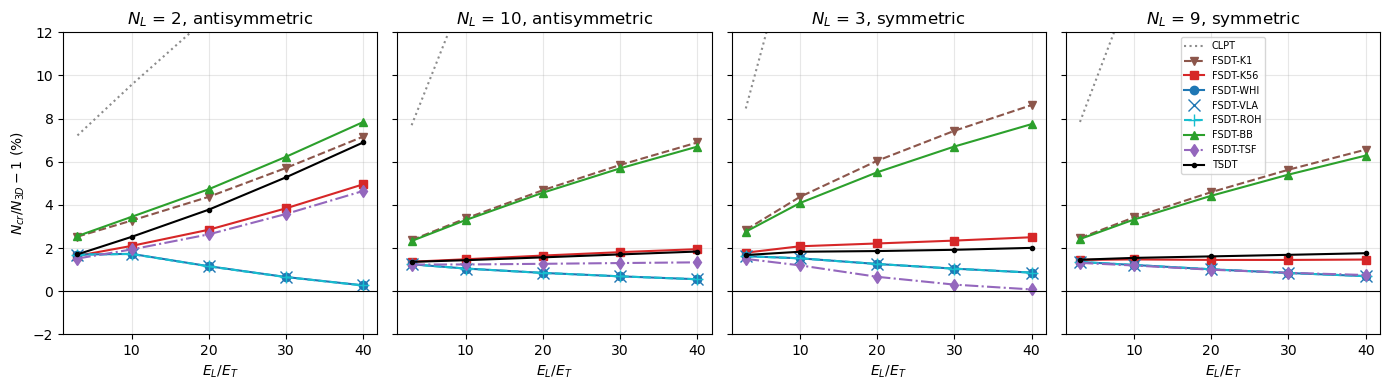

In [6]:
styles = {'CLPT': dict(color='0.55', ls=':'), 'FSDT-K1': dict(color='tab:brown', ls='--', marker='v'),
          'FSDT-K56': dict(color='tab:red', marker='s'), 'FSDT-WHI': dict(color='tab:blue', marker='o'),
          'FSDT-VLA': dict(color='tab:blue', ls='', marker='x', ms=9), 'FSDT-ROH': dict(color='tab:cyan', ls='--', marker='+', ms=9),
          'FSDT-BB': dict(color='tab:green', marker='^'), 'FSDT-TSF': dict(color='tab:purple', ls='-.', marker='d'),
          'TSDT': dict(color='k', marker='.')}
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
for ax, NL in zip(axes, (2, 10, 3, 9)):
    refs = su.NOOR_1975_TABLE_2[NL]
    for m in MODELS:
        e = [pct(res['T2 NL%d E%d' % (NL, E)][m]['N'], ref) for E, ref in zip(su.NOOR_E, refs)]
        ax.plot(su.NOOR_E, e, label=m, **styles[m])
    ax.axhline(0, color='k', lw=0.8)
    ax.set_ylim(-2, 12)
    ax.set_xlabel('$E_L/E_T$')
    ax.set_title('$N_L$ = %d, %s' % (NL, 'antisymmetric' if NL % 2 == 0 else 'symmetric'))
    ax.grid(alpha=0.3)
axes[0].set_ylabel('$N_{cr}/N_{3D} - 1$ (%)')
axes[-1].legend(fontsize=7)
plt.tight_layout()

The CLPT, +7% to +58%, is above the vertical limits of the figure.

## Table 3: $E_L/E_T = 30$, $a/h = 10$ and 5

Ratios $N_{FSDT}/N_{3D}$ of panels for $\kappa = 1$, $\kappa = 5/6$ and `'whitney'`, with the ratios printed by Noor in parentheses. Two values are given for each model: the critical load, and the load of the $(1, 1)$ mode, when the critical mode is another one.

In [7]:
rows = []
worst = 0.
for (ah, NL), (ref, *noor) in su.NOOR_1975_TABLE_3.items():
    r = res['T3 ah%d NL%d' % (ah, NL)]
    cells = []
    for k, rn in zip(('K1', 'K56', 'WHI'), noor):
        o = r['FSDT-' + k]
        txt = '%.3f (%.3f)' % (o['N']/ref, rn)
        if tuple(o['mode']) != (1, 1):
            txt = 'mode %s: %.3f; (1, 1): %.3f (%.3f)' % (tuple(o['mode']), o['N']/ref, o['N11']/ref, rn)
        worst = max(worst, abs(round(o['N11']/ref, 3) - rn))
        cells.append(txt)
    rows.append([ah, NL, '%.3f' % ref] + cells)
display(Markdown(markdown_table(['$a/h$', '$N_L$', '3D', '$\\kappa = 1$ (Noor)', '$\\kappa = 5/6$ (Noor)',
                                 "'whitney' (Noor's factors)"], rows)))
print('largest difference of the (1, 1) ratios to the printed ones: %.3f' % worst)

| $a/h$ | $N_L$ | 3D | $\kappa = 1$ (Noor) | $\kappa = 5/6$ (Noor) | 'whitney' (Noor's factors) |
|---|---|---|---|---|---|
| 10 | 2 | 9.375 | 1.057 (1.057) | 1.038 (1.038) | 1.007 (1.006) |
| 10 | 3 | 19.304 | 1.074 (1.074) | 1.023 (1.023) | 1.010 (1.010) |
| 10 | 9 | 20.961 | 1.056 (1.056) | 1.015 (1.014) | 1.008 (1.008) |
| 10 | 10 | 20.635 | 1.059 (1.058) | 1.018 (1.018) | 1.007 (1.007) |
| 5 | 2 | 6.664 | 1.171 (1.171) | 1.108 (1.108) | 1.011 (1.011) |
| 5 | 3 | 10.383 | 1.172 (1.172) | 1.062 (1.062) | 1.015 (1.015) |
| 5 | 9 | 12.138 | mode (2, 1): 1.071; (1, 1): 1.130 (1.130) | mode (2, 1): 0.927; (1, 1): 1.027 (1.027) | mode (2, 1): 0.950; (1, 1): 1.008 (1.008) |
| 5 | 10 | 12.070 | mode (2, 1): 1.052; (1, 1): 1.134 (1.134) | mode (2, 1): 0.914; (1, 1): 1.031 (1.031) | mode (2, 1): 0.881; (1, 1): 1.005 (1.005) |

largest difference of the (1, 1) ratios to the printed ones: 0.001


With the $(1, 1)$ mode, panels reproduces all 24 ratios printed by Noor within one unit of the third decimal, i.e. the FSDT of panels with $\kappa = 1$, $5/6$ and `'whitney'` is the shear deformation theory of Noor, and `'whitney'` reproduces his composite factors. For $a/h = 5$ and $N_L$ = 9, 10, however, the critical mode of the FSDT is not $(1, 1)$: modes with $m \ge 2$ half-waves along the load are lower, since for a thick plate the buckling load of the FSDT decreases towards the shear crippling load $A_{55}$ as $m$ increases. Noor's ratios, and very likely his 3D values, refer to the $(1, 1)$ mode, so that the comparison of the critical loads of these two rows with the 3D values is not valid (caveat of `p3_plate_monolithic_buckling.py`, part C, of the study). The next table gives the differences to 3D of all models, for the critical load and, in the second line, for the $(1, 1)$ mode.

In [8]:
rows = []
for (ah, NL), (ref, *noor) in su.NOOR_1975_TABLE_3.items():
    r = res['T3 ah%d NL%d' % (ah, NL)]
    rows.append([ah, NL, '%.3f' % ref, 'critical']
                + ['%+.1f%% %s' % (pct(r[m]['N'], ref), '' if tuple(r[m]['mode']) == (1, 1) else str(tuple(r[m]['mode'])))
                   if m in r else '-' for m in MODELS])
    if any(tuple(r[m]['mode']) != (1, 1) for m in r):
        rows.append(['', '', '', '(1, 1)'] + ['%+.1f%%' % pct(r[m]['N11'], ref) if m in r else '-' for m in MODELS])
display(Markdown(markdown_table(['$a/h$', '$N_L$', '3D', 'mode'] + MODELS, rows)))

| $a/h$ | $N_L$ | 3D | mode | CLPT | FSDT-K1 | FSDT-K56 | FSDT-WHI | FSDT-VLA | FSDT-ROH | FSDT-BB | FSDT-TSF | TSDT |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| 10 | 2 | 9.375 | critical | +16.2%  | +5.7%  | +3.8%  | +0.7%  | +0.7%  | +0.6%  | +6.2%  | +3.6%  | +5.3%  |
| 10 | 3 | 19.304 | critical | +44.7%  | +7.4%  | +2.3%  | +1.0%  | +1.0%  | +1.0%  | +6.7%  | +0.3%  | +1.9%  |
| 10 | 9 | 20.961 | critical | +33.3%  | +5.6%  | +1.5%  | +0.8%  | +0.8%  | +0.8%  | +5.4%  | +0.9%  | +1.7%  |
| 10 | 10 | 20.635 | critical | +32.1%  | +5.9%  | +1.8%  | +0.7%  | +0.7%  | +0.7%  | +5.7%  | +1.3%  | +1.7%  |
| 5 | 2 | 6.664 | critical | +63.4%  | +17.1%  | +10.8%  | +1.1%  | +1.1%  | +1.1%  | +18.9%  | +9.9%  | +15.9%  |
| 5 | 3 | 10.383 | critical | +169.1%  | +17.2%  | +6.2%  | +1.5%  | +1.5%  | +1.5%  | +16.0%  | +1.4% (2, 1) | +5.1%  |
|  |  |  | (1, 1) | +169.1% | +17.2% | +6.2% | +1.5% | +1.5% | +1.5% | +16.0% | +2.7% | +5.1% |
| 5 | 9 | 12.138 | critical | +130.2%  | +7.1% (2, 1) | -7.3% (2, 1) | -5.0% (2, 1) | -5.0% (2, 1) | -5.0% (2, 1) | +5.8% (2, 1) | -9.5% (2, 1) | +1.7% (2, 1) |
|  |  |  | (1, 1) | +130.2% | +13.0% | +2.7% | +0.8% | +0.8% | +0.8% | +12.5% | +1.4% | +3.4% |
| 5 | 10 | 12.070 | critical | +125.8%  | +5.2% (2, 1) | -8.6% (2, 1) | -11.9% (2, 1) | -11.9% (2, 1) | -11.9% (2, 1) | +4.6% (2, 1) | -10.1% (2, 1) | -5.8% (2, 1) |
|  |  |  | (1, 1) | +125.8% | +13.4% | +3.1% | +0.5% | +0.5% | +0.5% | +13.0% | +1.9% | +3.5% |

In [9]:
cols = {m: [pct(res['T3 ah5 NL%d' % NL][m]['N11'], su.NOOR_1975_TABLE_3[(5, NL)][0]) for NL in (2, 3, 9, 10)] for m in MODELS}
display(Markdown('**Table 3, $a/h = 5$, (1, 1) mode**'))
display(Markdown(su.stats_table(cols)))

**Table 3, $a/h = 5$, (1, 1) mode**

| model | max abs. diff. (%) | mean abs. diff. (%) | range (%) |
|---|---|---|---|
| CLPT | 169.1 | 122.1 | +63.4 to +169.1 |
| FSDT-K1 | 17.2 | 15.2 | +13.0 to +17.2 |
| FSDT-K56 | 10.8 | 5.7 | +2.7 to +10.8 |
| FSDT-WHI | 1.5 | 1.0 | +0.5 to +1.5 |
| FSDT-VLA | 1.5 | 1.0 | +0.5 to +1.5 |
| FSDT-ROH | 1.5 | 1.0 | +0.5 to +1.5 |
| FSDT-BB | 18.9 | 15.1 | +12.5 to +18.9 |
| FSDT-TSF | 9.9 | 4.0 | +1.4 to +9.9 |
| TSDT | 15.9 | 6.9 | +3.4 to +15.9 |

## Discussion

- **Noor's FSDT.** `'whitney'` reproduces the composite factors of Noor's Table 1 to the four printed digits for the eight laminates, and `'vlachoutsis'` gives the same values; those of `'rohwer'` differ by at most $4 \times 10^{-4}$. With these factors, $\kappa = 1$ and $\kappa = 5/6$, the FSDT of panels reproduces the 24 ratios $N_{SDT}/N_{3D}$ of Noor's Table 3 within 0.001, i.e. to the printed digits up to the rounding of the last one, provided the $(1, 1)$ mode is taken for $a/h = 5$.
- **Table 2, $a/h = 10$.** The static corrections `'whitney'`, `'vlachoutsis'` and `'rohwer'` are the closest to the 3D solution for all 35 laminates, $-0.1\%$ to $+1.7\%$ (mean 0.9%), and within 1.3% for $E_L/E_T \ge 20$. The TSDT is $+1.4\%$ to $+6.9\%$ (mean 2.5%) above, the largest values for the two-layer antisymmetric plate, $\kappa = 5/6$ $+1.4\%$ to $+7.2\%$, `'thickness_shear'` $+0.1\%$ to $+6.6\%$, $\kappa = 1$ and `'birman_bert'` (whose factors are close to 1 for these laminates) $+2.3\%$ to $+11.8\%$, and the CLPT $+7.2\%$ to $+58\%$. All the models overestimate the 3D load, and the error of the constant factors grows with the orthotropy $E_L/E_T$, since the transverse shear flexibility relative to the bending stiffness grows with it.
- **Table 3, $a/h = 5$.** For the $(1, 1)$ mode the static corrections are $+0.5\%$ to $+1.5\%$ from 3D, against $+2.7\%$ to $+10.8\%$ for $\kappa = 5/6$, $+3.4\%$ to $+15.9\%$ for the TSDT, $+12.5\%$ to $+18.9\%$ for $\kappa = 1$ and `'birman_bert'`, and $+63\%$ to $+169\%$ for the CLPT.
- **Critical mode of the thick plates.** For $a/h = 5$ and $N_L$ = 9, 10, the critical mode of every shear deformable model is $(2, 1)$, below the $(1, 1)$ mode: the critical loads are then $-5.0\%$ and $-11.9\%$ (static corrections), $-7.3\%$ and $-8.6\%$ ($\kappa = 5/6$) and $+1.7\%$ and $-5.8\%$ (TSDT) from the 3D values, which very likely refer to the $(1, 1)$ mode, as Noor's FSDT ratios do. These two rows are therefore not a valid comparison of the critical loads, and the comparison above uses the $(1, 1)$ mode.